<a href="https://colab.research.google.com/github/edgnbusra/churn-analizi-/blob/main/Churn_analyc%C4%B1sipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Telco Customer Churn veri setinin doğrudan bağlantısı
url = "https://raw.githubusercontent.com/pplonski/datasets-for-start/refs/heads/master/telco-customer-churn/Telco-Customer-Churn.csv"

# Veriyi pandas DataFrame'e okuma
df = pd.read_csv(url)

# İlk 5 satırı inceleme
print(df.head())



   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
# 1. Sütunların veri tiplerine ve eksik değerlere bakalım
print(df.info())

# 2. TotalCharges sütununda boşluk veya hatalı tip varsa düzeltelim
# (Genellikle boşluk karakteri olabiliyor, bunları NaN yapıp sayısal tipe çevireceğiz)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Eksik değer sayılarını kontrol edelim
print("\n--- Eksik Değerler ---")
print(df.isnull().sum())

# 3. Hedef değişkenimizin (Churn) dağılımına bakalım
print("\n--- Churn Dağılımı ---")
print(df['Churn'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# 1. TotalCharges içindeki eksik değerleri medyan ile dolduralım
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. customerID modeli eğitirken işimize yaramayacağı için düşelim
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 3. Hedef değişkenimiz Churn (Evet/Hayır) değerlerini 1 ve 0 yapalım
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Geri kalan tüm kategorik (metin türündeki) sütunları One-Hot Encoding ile sayısal yapalım
df = pd.get_dummies(df, drop_first=True)

# Sonucu ve sütun sayısını kontrol edelim
print("Ön işleme tamamlandı! Yeni veri boyutu:", df.shape)
print(df.head(2))

Ön işleme tamamlandı! Yeni veri boyutu: (7043, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            False   

   StreamingTV_Yes  StreamingMovies_No internet service  StreamingMovies_Yes  \
0            False                                False                False   
1            False                                False                False   

   Contract_One year  Contract_Two year  PaperlessBilling_Yes  \
0              False     

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Bağımsız değişkenler (X) ve hedef değişkeni (y) ayıralım
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Veriyi %80 eğitim, %20 test olarak bölelim
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. XGBoost modelini tanımlayalım ve eğitelim
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# 4. Test seti üzerinde tahmin yapalım
y_pred = xgb_model.predict(X_test)

# 5. Sonuçları değerlendirelim
print("--- Model Performansı ---")
print("Accuracy (Doğruluk):", accuracy_score(y_test, y_pred))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

--- Model Performansı ---
Accuracy (Doğruluk): 0.7743080198722498

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.77      0.77      1409



In [ ]:
# Gelişmiş parametrelerle XGBoost modelini yeniden kuralım
xgb_tuned = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Modeli eğitelim
xgb_tuned.fit(X_train, y_train)

# Tahmin yapalım
y_pred_tuned = xgb_tuned.predict(X_test)

# Yeni sonuçları görelim
print("--- İyileştirilmiş Model Performansı ---")
print("Accuracy (Doğruluk):", accuracy_score(y_test, y_pred_tuned))
print("\nYeni Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_tuned))

--- İyileştirilmiş Model Performansı ---
Accuracy (Doğruluk): 0.8041163946061036

Yeni Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



<Figure size 1000x800 with 0 Axes>

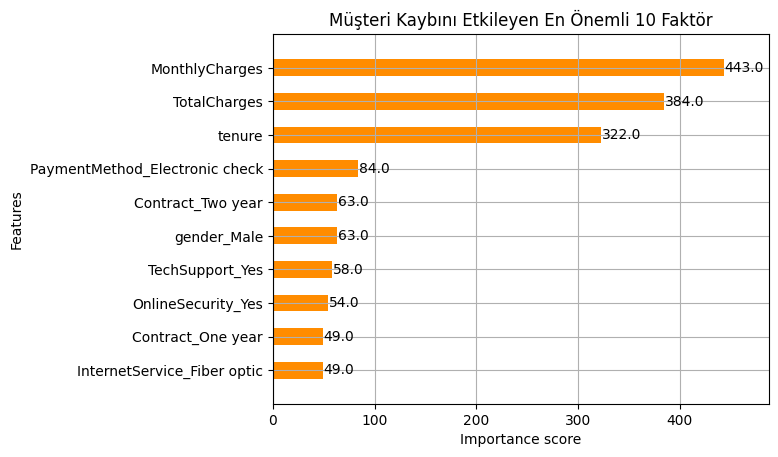

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# En önemli ilk 10 özellikleri görselleştirelim
plt.figure(figsize=(10, 8))
plot_importance(xgb_tuned, max_num_features=10, height=0.5, importance_type='weight', color='darkorange')
plt.title("Müşteri Kaybını Etkileyen En Önemli 10 Faktör")
plt.show()

In [ ]:
# 1. Sınıf dengesizlik oranını hesaplayalım (Churn=0 / Churn=1)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

print(f"Negatif sınıf sayısı: {neg_count}, Pozitif sınıf sayısı: {pos_count}")
print(f"Hesaplanan scale_pos_weight değeri: {scale_weight:.2f}")

# 2. Bu parametre ile XGBoost modelini güncelleyelim
xgb_balanced = XGBClassifier(
    learning_rate=0.05,
    max_depth=4,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_balanced.fit(X_train, y_train)
y_pred_balanced = xgb_balanced.predict(X_test)

print("\n--- Sınıf Dengesizliği Düzeltilmiş Model Raporu ---")
print(classification_report(y_test, y_pred_balanced))

Negatif sınıf sayısı: 4139, Pozitif sınıf sayısı: 1495
Hesaplanan scale_pos_weight değeri: 2.77

--- Sınıf Dengesizliği Düzeltilmiş Model Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 5 katlı stratifiye çapraz doğrulama tanımlayalım
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# F1 skoru üzerinden çapraz doğrulama yapalım
cv_scores = cross_val_score(xgb_balanced, X, y, cv=cv, scoring='f1')

print("--- 5 Katlı Çapraz Doğrulama Sonuçları ---")
print("Her bir katın F1 Skorları:", [f"{score:.4f}" for score in cv_scores])
print(f"Ortalama F1 Skoru: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

--- 5 Katlı Çapraz Doğrulama Sonuçları ---
Her bir katın F1 Skorları: ['0.6546', '0.6115', '0.6396', '0.6283', '0.6214']
Ortalama F1 Skoru: 0.6311 (+/- 0.0298)


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Olasılık tahminlerini alalım (Churn=1 olma olasılığı)
y_proba = xgb_balanced.predict_proba(X_test)[:, 1]

# 2. ROC eğrisi ve eşik değerlerini hesaplayalım
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
print(f"Model ROC-AUC Skoru: {auc_score:.4f}")

# 3. Youden İndeksi (Sensitivity + Specificity - 1) ile en iyi eşik değerini bulalım
# Bu indeks, yanlış pozitifleri ve yanlış negatifleri en iyi dengeleyen noktayı verir
j_scores = tpr - fpr
best_ix = np.argmax(j_scores)
best_threshold = thresholds[best_ix]

print(f"Optimal Eşik (Threshold) Değeri: {best_threshold:.4f}")

# 4. Yeni optimal eşik değerine göre tahminleri güncelleyelim
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print("\n--- Optimal Eşikli Model Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_optimal))

Model ROC-AUC Skoru: 0.8463
Optimal Eşik (Threshold) Değeri: 0.5067

--- Optimal Eşikli Model Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

